In [1]:
import numpy as np 
import meep as mp
from matplotlib import pyplot as plt
import meep.adjoint as mpa
import os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

design = np.load("data/final_design.npy")
dir2 = "flux2"
os.makedirs(dir2, exist_ok=True)

In [2]:
mp.verbosity(1)
Air = mp.Medium(index=1)
Si = mp.Medium(index=3.48)
resolution = 250

dx = 2.4  # design_region_x_width = 1    
dy = 0.8  # design_region_y_width = 1   
pml_size = 0.8
air_size = 0.8
Sx = dx + 2*pml_size + 0.1

Sy = dy + 2*pml_size + 2*air_size
cell_size = mp.Vector3(Sx, Sy)
# === 設計區尺寸與 cavity 區 ===
Nx = int(dx * resolution) + 1 
Ny = int(dy * resolution) + 1

design_2d = design.reshape(Nx,Ny)

# === Mapping 參數 ===
minimum_length = 0.02
eta_i = 0.5
eta_e = 0.55
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
pml_layers = [mp.PML(thickness=pml_size)]

# %%
# Design frequency
wavelengths = np.array([1.55])
frequencies = np.array([1 / 1.55])
fcen = 1. / 1.55
df = 0.1
source_center = mp.Vector3(0,0) 
source_size = mp.Vector3(0,0) 
src = mp.GaussianSource(frequency=fcen, fwidth=df)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
pml_layers = [mp.PML(thickness=pml_size)]

# %%

design_variables = mp.MaterialGrid(
mp.Vector3(Nx, Ny), 
medium1=Air,
medium2=Si,
weights=design_2d,
grid_type="U_MEAN"
)

design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(0,0,0),
        size=mp.Vector3(dx, dy,0),
    ),
)
geometry = [ 
    mp.Block(center=mp.Vector3(), size=mp.Vector3(Sx,dy), material=Si),
    mp.Block(center=mp.Vector3(), size=design_region.size, material=design_variables),
]  

sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    resolution=resolution,
    extra_materials=[Si],
)

In [3]:
nfreq = 100  
# top flux monitor
top_fr1 = mp.FluxRegion(
    center=mp.Vector3(0,dy/2,0), size=mp.Vector3(0.8,0,0)
)
top1 = sim.add_flux(fcen, df, nfreq, top_fr1)

# top_fr2 = mp.FluxRegion(
#     center=mp.Vector3(0,dy/2,0), size=mp.Vector3(0.2,0,0)
# )
# top2 = sim.add_flux(fcen, df, nfreq, top_fr2)

# top_fr3 = mp.FluxRegion(
#     center=mp.Vector3(dy/2-0.1,dy/2,0), size=mp.Vector3(0.2,0,0)
# )
# top3 = sim.add_flux(fcen, df, nfreq, top_fr3)

# right flux monitor
right_fr1 = mp.FluxRegion(
    center=mp.Vector3(0.4, 0, 0), size=mp.Vector3(0,0.8,0)
)
right1 = sim.add_flux(fcen, df, nfreq, right_fr1)

# right_fr2 = mp.FluxRegion(
#     center=mp.Vector3(0.4, 0, 0), size=mp.Vector3(0,0.2,0)
# )
# right2 = sim.add_flux(fcen, df, nfreq, right_fr2)

# right_fr3 = mp.FluxRegion(
#     center=mp.Vector3(0.4, -dy/2+0.1, 0), size=mp.Vector3(0,0.2,0)
# )
# right3 = sim.add_flux(fcen, df, nfreq, right_fr3)
# doewn flux monitor
down_fr1 = mp.FluxRegion(
    center=mp.Vector3(0,-dy/2,0), size=mp.Vector3(0.8,0,0)
)
down1 = sim.add_flux(fcen, df, nfreq, down_fr1)

# down_fr2 = mp.FluxRegion(
#     center=mp.Vector3(0,-dy/2,0), size=mp.Vector3(0.2,0,0)
# )
# down2 = sim.add_flux(fcen, df, nfreq, down_fr2)

# down_fr3 = mp.FluxRegion(
#     center=mp.Vector3(dy/2-0.1,-dy/2,0), size=mp.Vector3(0.2,0,0)
# )
# down3 = sim.add_flux(fcen, df, nfreq, down_fr3)
# left flux monitor
left_fr1 = mp.FluxRegion(
    center=mp.Vector3(-0.4, 0, 0), size=mp.Vector3(0, 0.8, 0)
)
left1 = sim.add_flux(fcen, df, nfreq, left_fr1)

# left_fr2 = mp.FluxRegion(
#     center=mp.Vector3(-0.4, 0, 0), size=mp.Vector3(0, 0.2, 0)
# )
# left2 = sim.add_flux(fcen, df, nfreq, left_fr2)

# left_fr3 = mp.FluxRegion(
#     center=mp.Vector3(-0.4, -0.3, 0), size=mp.Vector3(0, 0.2, 0)
# )
# left3 = sim.add_flux(fcen, df, nfreq, left_fr3)



     block, center = (0,0,0)
          size (4.1,0.8,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.1104,12.1104,12.1104)
     block, center = (0,0,0)
          size (2.4,0.8,0)
          axes (1,0,0), (0,1,0), (0,0,1)


<Axes: xlabel='X', ylabel='Y'>

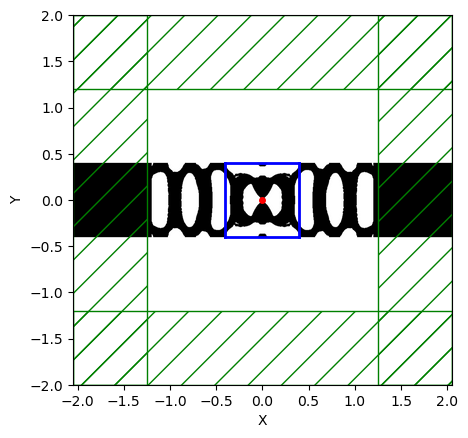

In [4]:
sim.plot2D()

In [5]:
pt = mp.Vector3(0, 0)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ey, pt, 1e-3))

top1_flux = mp.get_fluxes(top1)
# top2_flux = mp.get_fluxes(top2)
# top3_flux = mp.get_fluxes(top3)

down1_flux = mp.get_fluxes(down1)
# down2_flux = mp.get_fluxes(down2)
# down3_flux = mp.get_fluxes(down3)

right1_flux = mp.get_fluxes(right1)
# right2_flux = mp.get_fluxes(right2)
# right3_flux = mp.get_fluxes(right3)

left1_flux = mp.get_fluxes(left1)
# left2_flux = mp.get_fluxes(left2)
# left3_flux = mp.get_fluxes(left3)

flux_freqs = mp.get_flux_freqs(top1)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000859022 s
Working in 2D dimensions.
Computational cell is 4.1 x 4 x 0 with resolution 250
     block, center = (0,0,0)
          size (4.1,0.8,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.1104,12.1104,12.1104)
     block, center = (0,0,0)
          size (2.4,0.8,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 1.63036 s
-----------
on time step 769 (time=1.538), 0.00520268 s/step
on time step 1552 (time=3.104), 0.00511342 s/step
on time step 2335 (time=4.67), 0.00511409 s/step
on time step 3108 (time=6.216), 0.00517658 s/step
on time step 3870 (time=7.74), 0.00524993 s/step
on time step 4632 (time=9.264), 0.00525139 s/step
on time step 5395 (time=10.79), 0.00524923 s/step
on time step 6158 (time=12.316), 0.00524488 s/step
on time step 6921 (time=13.842), 0.00524388 s/step
on time step 7684 (time=15.368), 0.00524406 s/step
on time step 8447 (tim

In [6]:

flux_freqs = np.array(flux_freqs)
wl = 1 / flux_freqs

tf1 = np.array(top1_flux)
dof1 = np.array(down1_flux)
rf1 = np.array(right1_flux)
lf1 = np.array(left1_flux)

np.savez(
    f"{dir2}/flux.npz",
    freq=flux_freqs,
    wavelength=wl,
    top=tf1,
    down=dof1,
    right=rf1,
    left=lf1,
)


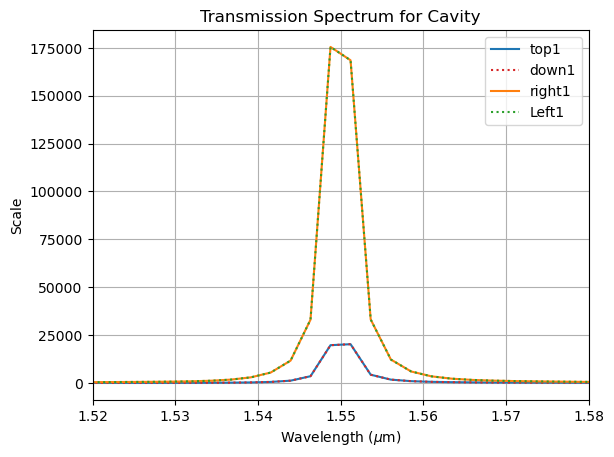

In [18]:
if mp.am_master():
    plt.figure(dpi=100)
    colors = plt.cm.tab10.colors
    linestyles = ["--", "-", ":"]
    plt.plot(wl, -tf1, linestyle=linestyles[1], color=colors[0], label="top1")
    plt.plot(wl, dof1,linestyle=linestyles[2], color=colors[3], label="down1")
    plt.plot(wl, rf1, linestyle=linestyles[1], color=colors[1], label="right1")
    plt.plot(wl, -lf1, linestyle=linestyles[2], color=colors[2], label="Left1")
    plt.xlim(1.52, 1.58)
    plt.xlabel(r"Wavelength ($\mu\mathrm{m}$)")
    plt.ylabel("Scale")
    plt.grid()
    plt.legend(loc="best")
    plt.title("Transmission Spectrum for Cavity")
    plt.savefig(f"{dir2}/figure4cavity_spectrum.png",dpi=300)
    plt.show()
    # plt.close()

In [8]:
# def plot_spectrum_wl(wl, tf,dof,rf,lf, save_path, transparent=True):
#     if mp.am_master():
#         plt.figure(dpi=150)
#         plt.plot(wl, tf, "b-", label="top ")
#         plt.plot(wl, dof,"r-", label="down")
#         plt.plot(wl, rf, "g-", label="right")
#         plt.plot(wl, lf, "y-", label="Left")
#         plt.xlim(1.4, 1.8)
#         plt.xlabel(r"Wavelength ($\mu\mathrm{m}$)")
#         plt.ylabel("Scale")
#         plt.grid()
#         plt.legend(loc="best")
#         plt.title("Transmission Spectrum for Cavity")
#         plt.savefig(save_path, transparent=transparent)
#         plt.show()
#         # plt.close()
# plot_spectrum_wl(wl, tf, dof, rf,lf,f"{dir2}/figure4cavity_spectrum.png", transparent=True)
# # plot_spectrum_wl(wl, Rs, Ts, f"{dir2}/figure4cavity_spectrum_background_fill.png", transparent=False)